# 05 - Análisis de Comportamiento de Usuarios (UBA)

Este cuaderno implementa técnicas de **User Behavior Analytics (UBA)** para detectar cuentas comprometidas y amenazas internas.

**Contenido:**
- Fundamentos del UBA
- Construcción de perfiles estadísticos de usuario
- Detección de comportamiento anómalo

## 6.1 Fundamentos del UBA

El **User Behavior Analytics (UBA)** consiste en establecer una línea base del comportamiento normal de los usuarios y detectar desviaciones que puedan indicar:

- Cuentas comprometidas
- Amenazas internas (insider threats)
- Movimiento lateral de atacantes

Se utilizan estadísticas descriptivas (media, desviación estándar, percentiles) y puntuaciones Z para identificar eventos fuera del rango habitual.

## 6.2 Generación de datos de actividad de usuarios

In [1]:
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------------
# Generar dataset sintético de logs de actividad si no existe
# ---------------------------------------------------------------
if not os.path.exists('user_activity_logs.csv'):
    print('Generando dataset sintético de logs de usuario...')
    rng = np.random.default_rng(42)
    n = 3000

    usuarios = ['ana.garcia', 'carlos.lopez', 'maria.perez', 'juan.rodriguez']
    ips_normales = {
        'ana.garcia'      : ['10.0.0.1', '10.0.0.2', '192.168.1.10'],
        'carlos.lopez'    : ['10.0.1.5', '10.0.1.6', '192.168.1.20'],
        'maria.perez'     : ['10.0.2.3', '10.0.2.4', '192.168.1.30'],
        'juan.rodriguez'  : ['10.0.3.7', '10.0.3.8', '192.168.1.40'],
    }

    registros = []
    for _ in range(n):
        user = rng.choice(usuarios)
        # Hora de login: distribución normal centrada en horario laboral (9h)
        hora = float(np.clip(rng.normal(9.0, 1.5), 0, 23))
        # IP: 90% desde IPs conocidas, 10% desde IPs externas
        if rng.random() < 0.9:
            ip = rng.choice(ips_normales[user])
        else:
            ip = f'{rng.integers(1,255)}.{rng.integers(1,255)}.{rng.integers(1,255)}.{rng.integers(1,255)}'
        bytes_sent    = float(rng.exponential(50_000))
        failed_logins = int(rng.poisson(0.3))
        registros.append({
            'user'         : user,
            'hora_login'   : round(hora, 2),
            'ip_origen'    : ip,
            'bytes_sent'   : round(bytes_sent, 2),
            'failed_logins': failed_logins
        })

    logs_df = pd.DataFrame(registros)
    logs_df.to_csv('user_activity_logs.csv', index=False)
    print(f'Dataset creado: {n} registros para {len(usuarios)} usuarios.')
else:
    logs_df = pd.read_csv('user_activity_logs.csv')
    print(f'Dataset cargado: {len(logs_df)} registros.')

print(logs_df.head())
print(f'\nUsuarios únicos: {logs_df["user"].unique()}')

Generando dataset sintético de logs de usuario...
Dataset creado: 3000 registros para 4 usuarios.
           user  hora_login        ip_origen  bytes_sent  failed_logins
0    ana.garcia        7.44     192.168.1.10    13989.71              0
1   maria.perez        9.19     192.168.1.30     3964.71              0
2   maria.perez       10.17         10.0.2.4    19344.74              0
3  carlos.lopez        9.55         10.0.1.5    45059.96              0
4    ana.garcia        7.98  193.114.227.173    20854.34              0

Usuarios únicos: ['ana.garcia' 'maria.perez' 'carlos.lopez' 'juan.rodriguez']


## 6.3 Construcción de perfiles de usuario

In [2]:
from scipy import stats

def construir_perfil_usuario(logs: pd.DataFrame, usuario: str) -> dict:
    """
    Construye un perfil estadístico del usuario a partir
    de registros de actividad (logs).
    """
    datos_usuario = logs[logs['user'] == usuario]

    if datos_usuario.empty:
        raise ValueError(f'No se encontraron registros para el usuario: {usuario}')

    perfil = {
        'usuario'             : usuario,
        'hora_media_login'    : datos_usuario['hora_login'].mean(),
        'hora_std_login'      : datos_usuario['hora_login'].std(),
        'ip_frecuentes'       : datos_usuario['ip_origen'].value_counts()
                                    .head(5).index.tolist(),
        'bytes_enviados_media': datos_usuario['bytes_sent'].mean(),
        'bytes_enviados_std'  : datos_usuario['bytes_sent'].std(),
        'accesos_fallidos_p95': datos_usuario['failed_logins'].quantile(0.95),
        'total_registros'     : len(datos_usuario),
    }
    return perfil


# Construir perfil para ana.garcia
logs = pd.read_csv('user_activity_logs.csv')
perfil_ana = construir_perfil_usuario(logs, usuario='ana.garcia')

print('=== Perfil de ana.garcia ===')
for k, v in perfil_ana.items():
    print(f'  {k:<28}: {v}')

=== Perfil de ana.garcia ===
  usuario                     : ana.garcia
  hora_media_login            : 8.881012987012987
  hora_std_login              : 1.5575738903045004
  ip_frecuentes               : ['10.0.0.1', '192.168.1.10', '10.0.0.2', '159.191.43.5', '113.254.47.209']
  bytes_enviados_media        : 48214.940025974014
  bytes_enviados_std          : 47058.52497070067
  accesos_fallidos_p95        : 1.0
  total_registros             : 770


## 6.4 Detección de comportamiento anómalo

In [3]:
def detectar_comportamiento_anomalo(evento: dict,
                                     perfil: dict,
                                     umbral_z: float = 3.0) -> list:
    """
    Compara un evento con el perfil histórico.
    Devuelve lista de alertas generadas.
    """
    alertas = []

    # Hora de inicio de sesión fuera del rango habitual
    if perfil['hora_std_login'] > 0:
        z_hora = abs(
            (evento['hora_login'] - perfil['hora_media_login'])
            / perfil['hora_std_login']
        )
        if z_hora > umbral_z:
            alertas.append(
                f'Inicio de sesión en hora inusual '
                f'(z={z_hora:.2f}): {evento["hora_login"]}h'
            )

    # Acceso desde IP desconocida
    if evento['ip_origen'] not in perfil['ip_frecuentes']:
        alertas.append(
            f'Acceso desde IP no habitual: {evento["ip_origen"]}'
        )

    # Volumen de datos elevado
    if (perfil['bytes_enviados_std'] > 0 and
            evento['bytes_sent'] >
            perfil['bytes_enviados_media'] + umbral_z * perfil['bytes_enviados_std']):
        alertas.append(
            f'Volumen de datos inusual: {evento["bytes_sent"]:,.0f} bytes'
        )

    return alertas


# Evento sospechoso: login a las 3:30 AM desde IP externa con 500 MB
evento_sospechoso = {
    'hora_login' : 3.5,          # 3:30 AM
    'ip_origen'  : '45.33.32.156',
    'bytes_sent' : 500_000_000   # 500 MB
}

alertas = detectar_comportamiento_anomalo(evento_sospechoso, perfil_ana)
if alertas:
    print(f"[!] ALERTAS para '{perfil_ana['usuario']}':")
    for alerta in alertas:
        print(f'    {alerta}')
else:
    print('Comportamiento dentro del perfil habitual.')

print()

# Evento normal: login a las 9:15 AM desde IP conocida
evento_normal = {
    'hora_login' : 9.25,
    'ip_origen'  : perfil_ana['ip_frecuentes'][0],
    'bytes_sent' : 30_000
}
alertas_normal = detectar_comportamiento_anomalo(evento_normal, perfil_ana)
if alertas_normal:
    print(f"[!] ALERTAS para '{perfil_ana['usuario']}':")
    for alerta in alertas_normal:
        print(f'    {alerta}')
else:
    print('Evento normal: comportamiento dentro del perfil habitual.')

[!] ALERTAS para 'ana.garcia':
    Inicio de sesión en hora inusual (z=3.45): 3.5h
    Acceso desde IP no habitual: 45.33.32.156
    Volumen de datos inusual: 500,000,000 bytes

Evento normal: comportamiento dentro del perfil habitual.


## 6.5 Análisis masivo de todos los usuarios

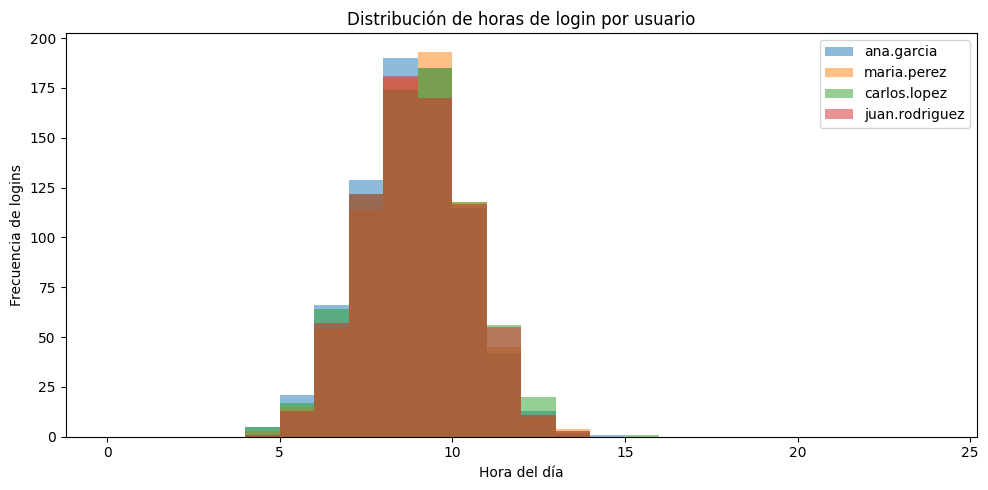

Gráfico guardado: uba_login_hours.png

=== Resumen de perfiles ===
       usuario  hora_media_login  hora_std_login  bytes_media  total_registros
    ana.garcia              8.88            1.56      48215.0              770
   maria.perez              8.95            1.49      52339.0              736
  carlos.lopez              8.99            1.60      51953.0              764
juan.rodriguez              8.99            1.51      49306.0              730


In [4]:
import matplotlib.pyplot as plt

# Construir perfiles para todos los usuarios
usuarios = logs['user'].unique()
perfiles = {u: construir_perfil_usuario(logs, u) for u in usuarios}

# Visualizar hora media de login por usuario
fig, ax = plt.subplots(figsize=(10, 5))
for usuario, perfil in perfiles.items():
    datos = logs[logs['user'] == usuario]['hora_login']
    ax.hist(datos, bins=24, alpha=0.5, label=usuario, range=(0, 24))

ax.set_xlabel('Hora del día')
ax.set_ylabel('Frecuencia de logins')
ax.set_title('Distribución de horas de login por usuario')
ax.legend()
plt.tight_layout()
plt.savefig('uba_login_hours.png', dpi=150)
plt.show()
print('Gráfico guardado: uba_login_hours.png')

# Resumen de perfiles
print('\n=== Resumen de perfiles ===')
resumen = pd.DataFrame([
    {
        'usuario'          : p['usuario'],
        'hora_media_login' : round(p['hora_media_login'], 2),
        'hora_std_login'   : round(p['hora_std_login'], 2),
        'bytes_media'      : round(p['bytes_enviados_media'], 0),
        'total_registros'  : p['total_registros'],
    }
    for p in perfiles.values()
])
print(resumen.to_string(index=False))